# 518880 Mid Stall 策略演示

这个 notebook 展示 `518880/` 下新建的最简策略原型：
- 事件：`mid_price` 连续 `i` 秒不动
- 标签：未来 `10s` 内是否先触及 `2 tick`
- 模型：先用最简单的分类器验证方向可预测性
- 策略：高置信度时开仓，`2 tick` 止盈止损或 `10s` 超时平仓


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import sys
import pickle
from pathlib import Path

ROOT = Path('/home/jovyan/work/tactics_demo')
MODULE_DIR = ROOT / '518880'

for path in [ROOT, MODULE_DIR, ROOT / 'tools']:
    if str(path) not in sys.path:
        sys.path.append(str(path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


## 导入模块


In [3]:
from data_processing import get_valid_trade_dates, samples_from_dates, split_dates
from main import build_model, find_best_threshold, DEFAULT_PARAMS, run_strategy_for_day
from strategy import StrategyDemo
from features import create_feature


## 设置参数

这里先用和当前脚本一致的默认参数，便于 notebook 和 `main.py` 保持一致。


In [4]:
instrument_id = '518880'

param_dict = dict(DEFAULT_PARAMS)
param_dict.update({
    'instrument_id': instrument_id,
    'name': 'mid_stall_demo',
    'start_ymd': '20250901',
    'end_ymd': '20260425',
    'x_window': 60,
    'stall_seconds': 5,
    'horizon_seconds': 10,
    'target_ticks': 2,
    'stride': 1,
    'model_type': 'xgboost',
})

param_dict


{'instrument_id': '518880',
 'name': 'mid_stall_demo',
 'tick_size': 0.001,
 'x_window': 60,
 'stall_seconds': 5,
 'horizon_seconds': 10,
 'target_ticks': 2,
 'stride': 1,
 'allow_no_touch': False,
 'prob_threshold': 0.6,
 'start_ymd': '20250901',
 'end_ymd': '20260425',
 'model_type': 'xgboost'}

## 获取交易日并切分数据集


In [5]:
trade_dates = get_valid_trade_dates(
    instrument_id=param_dict['instrument_id'],
    start_ymd=param_dict['start_ymd'],
    end_ymd=param_dict['end_ymd'],
)
train_dates, valid_dates, test_dates = split_dates(trade_dates)

print(f'总交易日数量: {len(trade_dates)}')
print(f'交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}')
print(f'train: {train_dates[0]} ~ {train_dates[-1]} ({len(train_dates)})')
print(f'valid: {valid_dates[0]} ~ {valid_dates[-1]} ({len(valid_dates)})')
print(f'test : {test_dates[0]} ~ {test_dates[-1]} ({len(test_dates)})')


总交易日数量: 79
交易日范围: 20250901 ~ 20260423
train: 20250901 ~ 20260115 (47)
valid: 20260119 ~ 20260311 (16)
test : 20260313 ~ 20260423 (16)


## 生成样本


In [6]:
X_train, y_train, feature_names = samples_from_dates(train_dates, instrument_id, param_dict)
X_valid, y_valid, _ = samples_from_dates(valid_dates, instrument_id, param_dict)
X_test, y_test, _ = samples_from_dates(test_dates, instrument_id, param_dict)

print(f'训练集样本: X={X_train.shape}, y={y_train.shape}')
print(f'验证集样本: X={X_valid.shape}, y={y_valid.shape}')
print(f'测试集样本: X={X_test.shape}, y={y_test.shape}')
print(f'特征数量: {len(feature_names)}')

feature_names


20250901: 样本=129, up_ratio=0.581
20250903: 样本=32, up_ratio=0.469
20250905: 样本=15, up_ratio=0.467
20250909: 样本=51, up_ratio=0.549
20250911: 样本=34, up_ratio=0.559
20250915: 样本=15, up_ratio=0.600
20250917: 样本=72, up_ratio=0.444
20250919: 样本=44, up_ratio=0.500
20250923: 样本=57, up_ratio=0.561
20250925: 样本=23, up_ratio=0.391
20250929: 样本=68, up_ratio=0.574
20251009: 样本=102, up_ratio=0.510
20251013: 样本=121, up_ratio=0.471
20251015: 样本=128, up_ratio=0.484
20251017: 样本=218, up_ratio=0.523
20251021: 样本=192, up_ratio=0.557
20251023: 样本=162, up_ratio=0.506
20251027: 样本=72, up_ratio=0.472
20251029: 样本=111, up_ratio=0.532
20251031: 样本=193, up_ratio=0.440
20251103: 样本=142, up_ratio=0.535
20251105: 样本=90, up_ratio=0.500
20251107: 样本=16, up_ratio=0.375
20251111: 样本=47, up_ratio=0.426
20251113: 样本=99, up_ratio=0.495
20251117: 样本=132, up_ratio=0.462
20251119: 样本=86, up_ratio=0.581
20251121: 样本=160, up_ratio=0.487
20251125: 样本=45, up_ratio=0.489
20251127: 样本=15, up_ratio=0.533
20251201: 样本=103, up_ratio=0

['stall_seconds',
 'spread_ticks_last',
 'spread_ticks_mean',
 'mid_range_ticks',
 'last_return_ticks',
 'l1_imbalance_last',
 'l3_imbalance_last',
 'l5_imbalance_last',
 'l1_imbalance_mean',
 'l3_imbalance_mean',
 'l5_imbalance_mean',
 'l1_imbalance_change',
 'l5_imbalance_change',
 'bid_l1_change',
 'ask_l1_change',
 'bid_l5_change',
 'ask_l5_change',
 'cum_buy_vol',
 'cum_sell_vol',
 'cum_net_active_vol',
 'cum_active_vol_imbalance',
 'cum_buy_turnover',
 'cum_sell_turnover',
 'cum_net_active_turnover',
 'cum_trade_count',
 'active_seconds_ratio']

In [7]:
pd.DataFrame({
    'train': pd.Series(y_train).value_counts().sort_index(),
    'valid': pd.Series(y_valid).value_counts().sort_index(),
    'test': pd.Series(y_test).value_counts().sort_index(),
}).fillna(0).astype(int)


,train,valid,test
0,2003,1238,1209
1,1997,1246,1166


In [8]:
sample_summary = pd.DataFrame([
    {'split': 'train', 'samples': len(y_train), 'up_ratio': float(np.mean(y_train == 1))},
    {'split': 'valid', 'samples': len(y_valid), 'up_ratio': float(np.mean(y_valid == 1))},
    {'split': 'test', 'samples': len(y_test), 'up_ratio': float(np.mean(y_test == 1))},
])
sample_summary


,split,samples,up_ratio
0,train,4000,0.4993
1,valid,2484,0.5016
2,test,2375,0.4909


## 训练模型


In [9]:
model = build_model(param_dict['model_type'])

if param_dict['model_type'] == 'xgboost':
    model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
else:
    model.fit(X_train, y_train)

valid_prob = model.predict_proba(X_valid)[:, 1]
threshold = find_best_threshold(y_valid, valid_prob)
param_dict['prob_threshold'] = threshold

print(f'selected_threshold = {threshold:.2f}')


selected_threshold = 0.72


In [10]:
def summarize_predictions(split_name, y_true, y_prob, threshold):
    decided_mask = (y_prob >= threshold) | (y_prob <= 1 - threshold)
    decided_samples = int(decided_mask.sum())
    row = {
        'split': split_name,
        'samples': len(y_true),
        'accuracy@0.5': float(((y_prob >= 0.5).astype(int) == y_true).mean()),
        f'decided_ratio@{threshold:.2f}': float(decided_mask.mean()),
    }
    if decided_samples > 0:
        decided_pred = (y_prob[decided_mask] >= threshold).astype(int)
        row['decided_samples'] = decided_samples
        row['accuracy@decided'] = float((decided_pred == y_true[decided_mask]).mean())
    return row

train_prob = model.predict_proba(X_train)[:, 1]
test_prob = model.predict_proba(X_test)[:, 1]

pd.DataFrame([
    summarize_predictions('train', y_train, train_prob, threshold),
    summarize_predictions('valid', y_valid, valid_prob, threshold),
    summarize_predictions('test', y_test, test_prob, threshold),
])


,split,samples,accuracy@0.5,decided_ratio@0.72,decided_samples,accuracy@decided
0,train,4000,0.7618,0.3785,1514,0.9359
1,valid,2484,0.6212,0.3756,933,0.7160
2,test,2375,0.6383,0.4147,985,0.7249


,feature,importance
0,l1_imbalance_last,0.1524
1,l3_imbalance_last,0.1083
2,l3_imbalance_mean,0.0404
3,l1_imbalance_change,0.0397
4,cum_sell_vol,0.0366
5,cum_net_active_turnover,0.0364
6,last_return_ticks,0.0363
7,cum_buy_turnover,0.0355
8,spread_ticks_mean,0.0354
9,mid_range_ticks,0.0353


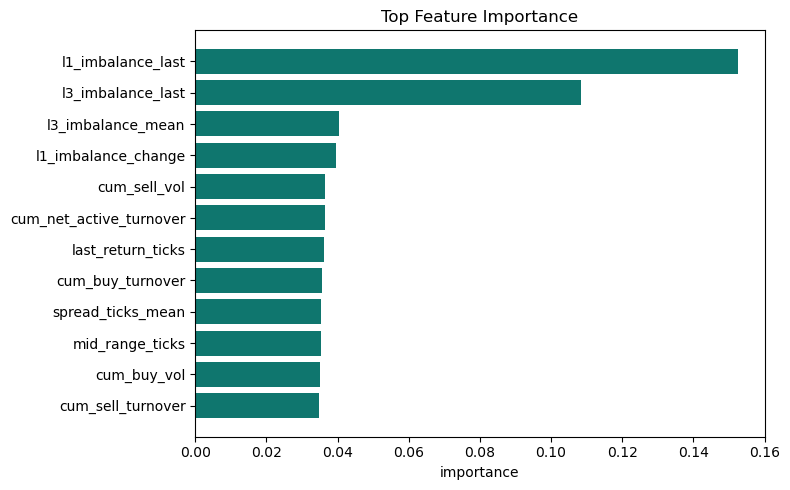

In [11]:
if hasattr(model, 'feature_importances_'):
    importance_df = (
        pd.DataFrame({'feature': feature_names, 'importance': model.feature_importances_})
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )
    display(importance_df.head(15))

    plt.figure(figsize=(8, 5))
    topk = importance_df.head(12).iloc[::-1]
    plt.barh(topk['feature'], topk['importance'], color='#0f766e')
    plt.title('Top Feature Importance')
    plt.xlabel('importance')
    plt.tight_layout()
    plt.show()


## 看一下高置信样本的概率分布


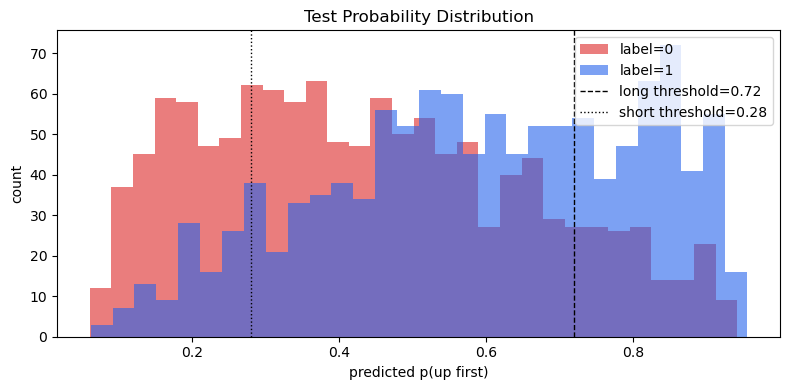

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(test_prob[y_test == 0], bins=30, alpha=0.6, label='label=0', color='#dc2626')
plt.hist(test_prob[y_test == 1], bins=30, alpha=0.6, label='label=1', color='#2563eb')
plt.axvline(threshold, color='black', linestyle='--', linewidth=1, label=f'long threshold={threshold:.2f}')
plt.axvline(1 - threshold, color='black', linestyle=':', linewidth=1, label=f'short threshold={1-threshold:.2f}')
plt.title('Test Probability Distribution')
plt.xlabel('predicted p(up first)')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()


## 创建 artifact 与策略实例


In [13]:
artifact = {
    'model': model,
    'feature_names': feature_names,
    'threshold': threshold,
    'param_dict': dict(param_dict),
}

artifact_path = MODULE_DIR / 'data' / f"{param_dict['name']}_artifact.pkl"
artifact_path.parent.mkdir(parents=True, exist_ok=True)
with open(artifact_path, 'wb') as f:
    pickle.dump(artifact, f)

model_path = str(artifact_path)
strategy = StrategyDemo(model_path, param_dict)
print(model_path)
strategy


/home/jovyan/work/tactics_demo/518880/data/mid_stall_demo_artifact.pkl


## 单日回测观察

先看测试集最后一个交易日的最简回测结果。


-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 79 个有数据的交易日
-> 过滤后剩余 5 个有数据的交易日
-> 过滤掉 6 个无数据日期: ['20260414', '20260416', '20260418', '20260419', '20260420', '20260422']
-> 回测标的: 518880 (20260413 - 20260423)
-> 任务分配: 共 5 天，使用 3 个核心并行计算...
[SpawnPoolWorker-2] 日期 20260417 完成 | 盈亏: -21.10 | 成交: 297次 | 胜率: 11.9% | 平均持仓: 10.6快照
[SpawnPoolWorker-3] 日期 20260423 完成 | 盈亏: -26.10 | 成交: 303次 | 胜率: 14.7% | 平均持仓: 10.3快照
[SpawnPoolWorker-1] 日期 20260413 完成 | 盈亏: -28.30 | 成交: 298次 | 胜率: 10.6% | 平均持仓: 10.7快照
[SpawnPoolWorker-2] 日期 20260421 完成 | 盈亏: -23.90 | 成交: 292次 | 胜率: 7.8% | 平均持仓: 10.7快照
[SpawnPoolWorker-1] 日期 20260415 完成 | 盈亏: -26.20 | 成交: 316次 | 胜率: 11.8% | 平均持仓: 10.5快照
回测结束，强制终止所有子进程

多日回测汇总统计
测试天数: 5
累计总盈亏: -125.60
总成交次数: 1506
盈利交易次数: 179
亏损交易次数: 1394
加权每手胜率: 11.89%
每笔交易平均盈亏: -0.08
加权平均持仓时间: 10.57 快照


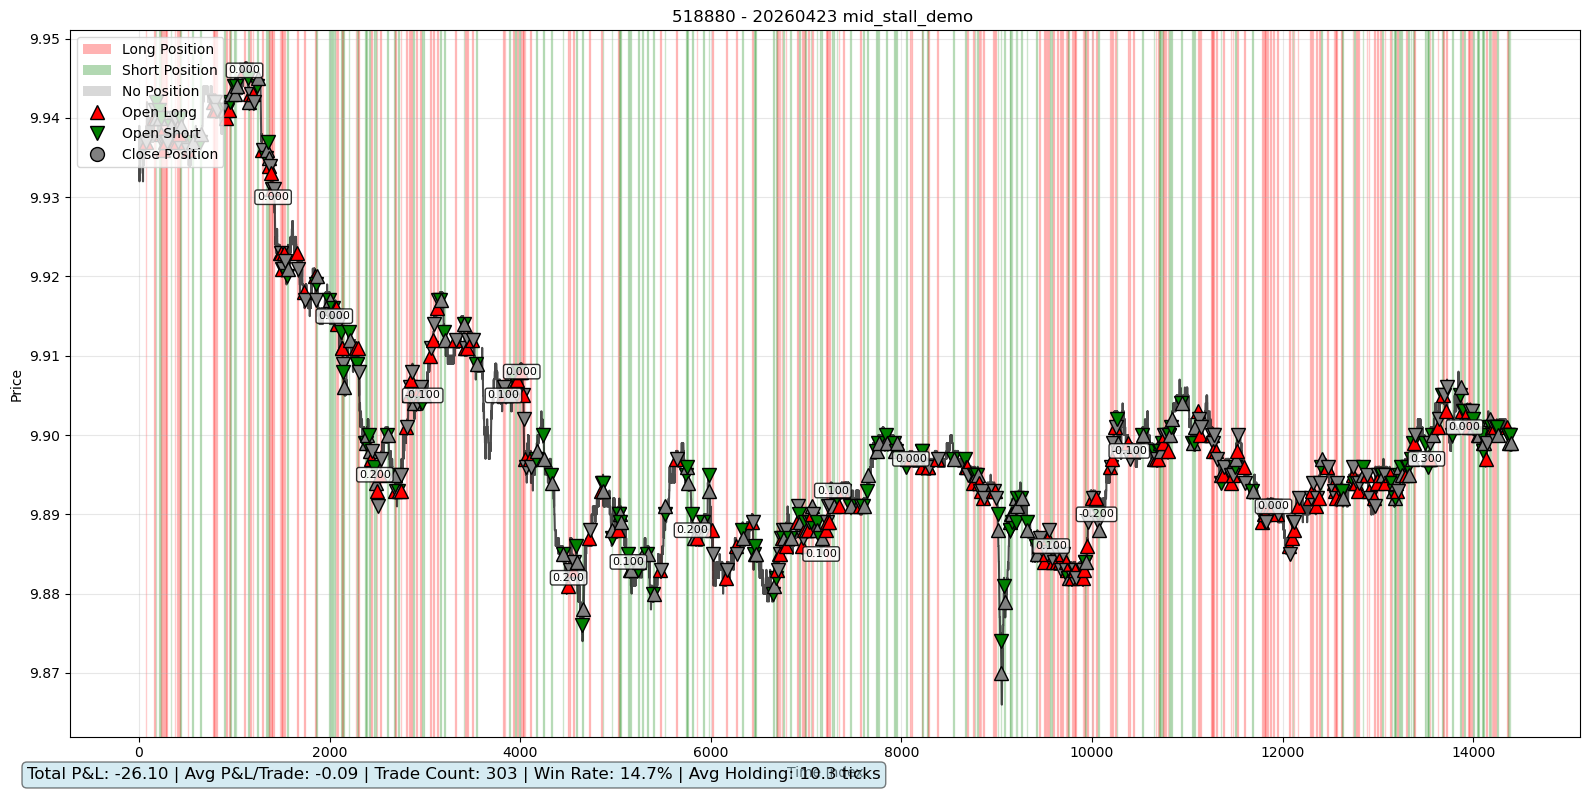

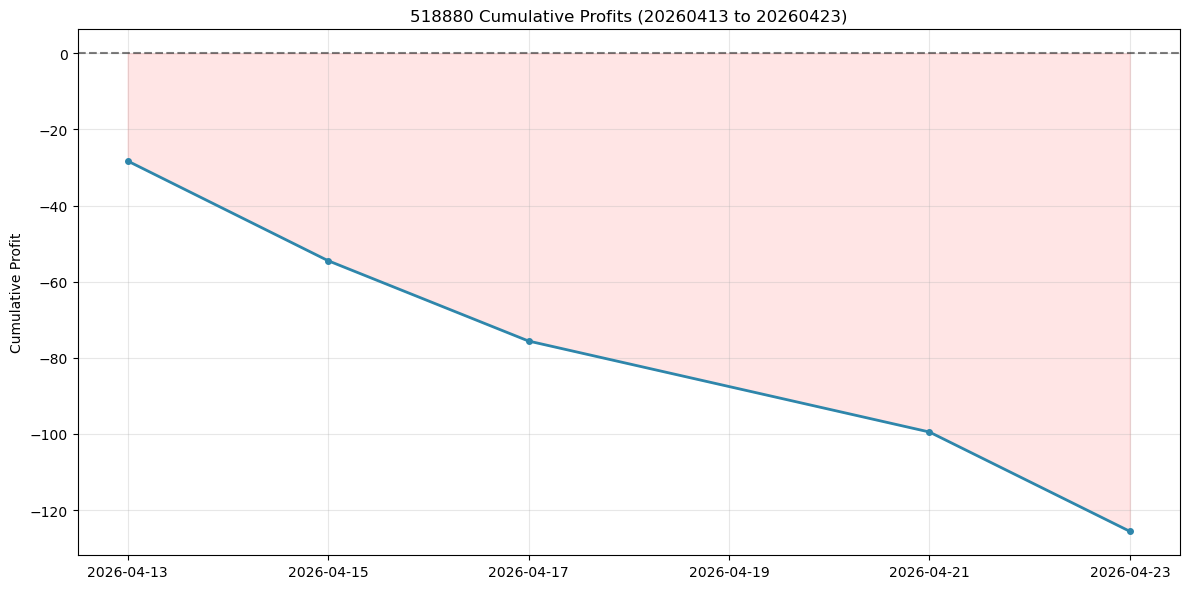

({'final_pnl': np.float64(-26.099999999999454),
  'price_history': array([9.935, 9.938, 9.938, ..., 9.899, 9.898, 9.898], shape=(14402,)),
  'position_history': array([0, 0, 0, ..., 0, 0, 0], shape=(14402,)),
  'change_indices': array([   73,    78,   160,   170,   178,   183,   214,   224,   227,
           237,   247,   254,   264,   275,   285,   286,   296,   332,
           342,   374,   380,   400,   410,   417,   427,   429,   439,
           510,   520,   557,   567,   641,   651,   774,   784,   790,
           800,   810,   820,   891,   901,   917,   927,   950,   960,
           970,   995,  1005,  1015,  1025,  1099,  1119,  1145,  1155,
          1166,  1176,  1193,  1203,  1244,  1254,  1293,  1303,  1337,
          1347,  1357,  1367,  1368,  1378,  1386,  1395,  1399,  1419,
          1476,  1486,  1488,  1498,  1501,  1511,  1524,  1534,  1551,
          1561,  1662,  1672,  1730,  1740,  1848,  1854,  1861,  1868,
          1991,  2001,  2018,  2028,  2041,  2061,  2

In [14]:
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
from multi_day_backtest import backtest_multi_days
from single_day_backtest import single_day_backtest, plot_delta_history

single_day_result = single_day_backtest(
    instrument_id,
    test_dates[-1],
    StrategyDemo,
    model_path,
    param_dict,
    official=False,
)

parallel_result = run_parallel_backtest(
    instrument_id,
    test_dates[-5],
    test_dates[-1],
    StrategyDemo,
    model_path,
    param_dict,
    n_cores=4,
)

single_day_result, backtest_summary(parallel_result)


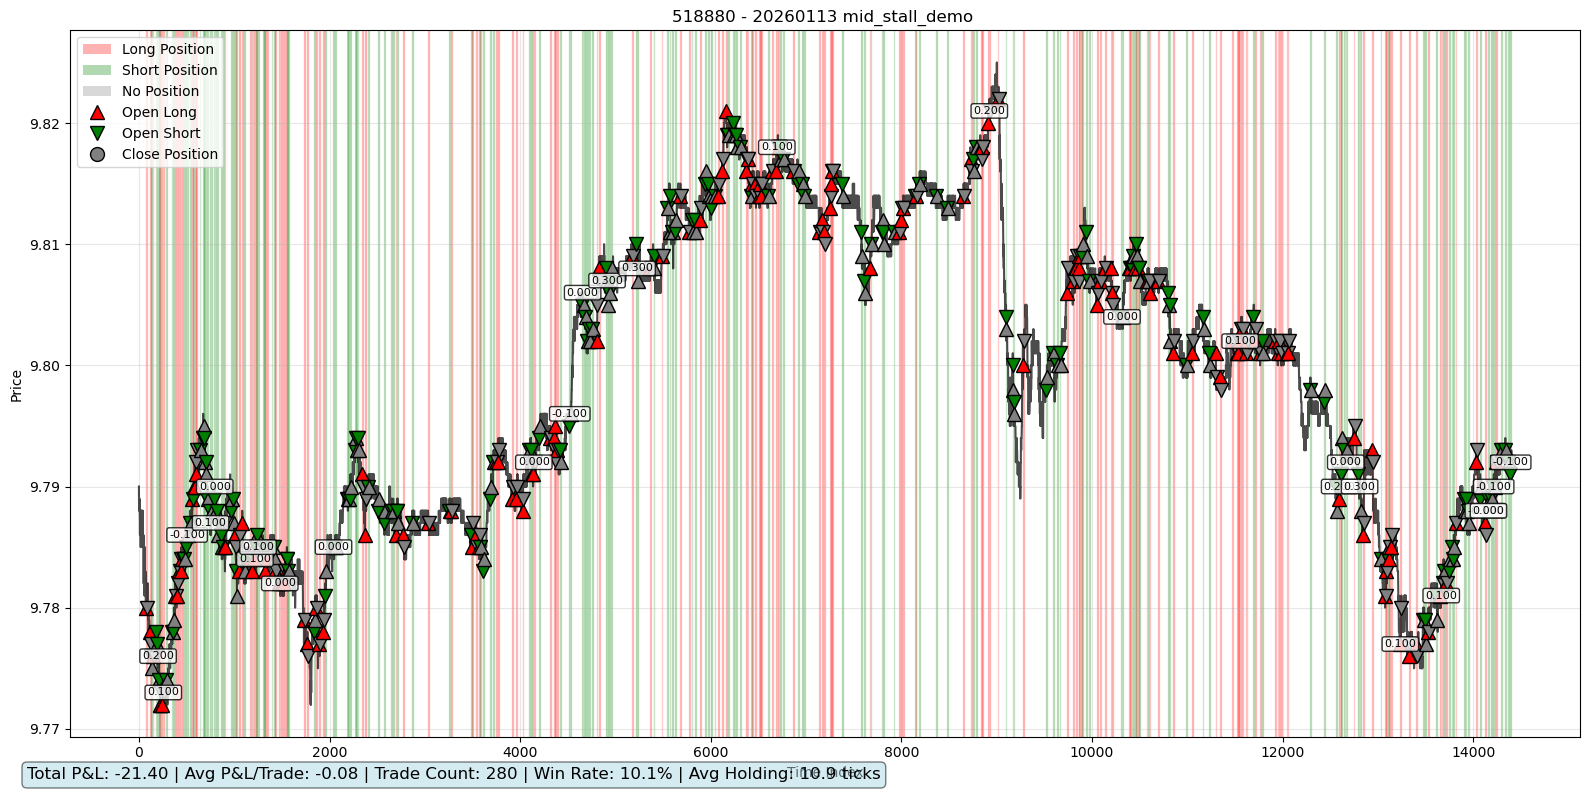

In [15]:
single_day_result = single_day_backtest(
    instrument_id,
    '20260113',
    StrategyDemo,
    model_path,
    param_dict,
    official=False,
)

## 备注

这份 notebook 的目标只是展示“事件触发 + 打标 + 训练 + 回测”的最简闭环。
当前回测结果还不代表策略已经可交易，后面更值得继续调的是：
- `stall_seconds`
- `horizon_seconds`
- `target_ticks`
- `x_window`
- 开仓阈值与出场规则
